# 경량 CNN 기반 알츠하이머 MRI 분류 + Grad-CAM 분석

데이터셋: Non_Demented / Very_Mild_Demented / Mild_Demented (3-class)

진행 순서: 데이터 로딩 → 모델 정의 → 학습 → 검증 → 테스트 → Grad-CAM 시각화

## 0. 환경 설정 및 경로 지정

**주의**: 탐색기 구조를 보면 `Alzheimer_Split/Alzheimer_Split/{train,val,test}` 처럼
폴더가 한 번 중첩되어 있습니다. 아래 `DATA_ROOT` 경로를 본인 환경에 맞게 수정하세요.

In [4]:
import sys
print(sys.executable)

c:\Users\serra\anaconda3\python.exe


In [7]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio

   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 1.3/123.0 MB 9.6 MB/s eta 0:00:13
   - -------------------------------------- 4.2/123.0 MB 11.0 MB/s eta 0:00:11
   -- ------------------------------------- 6.3/123.0 MB 10.7 MB/s eta 0:00:11
   -- ------------------------------------- 8.7/123.0 MB 10.7 MB/s eta 0:00:11
   --- ------------------------------------ 11.3/123.0 MB 11.2 MB/s eta 0:00:10
   ---- ----------------------------------- 14.9/123.0 MB 12.0 MB/s eta 0:00:09
   ------ --------------------------------- 18.9/123.0 MB 13.0 MB/s eta 0:00:09
   ------- -------------------------------- 22.5/123.0 MB 13.3 MB/s eta 0:00:08
   -------- ------------------------------- 26.7/123.0 MB 13.9 MB/s eta 0:00:07
   --------- ------------------------------ 29.6/123.0 MB 13.9 MB/s eta 0:00:07
   ---------- ----------------------------- 33.8/123.0 MB 14.4 MB/s eta 0:00:07
   ----------- ---------------------------- 34.9/123.0

In [8]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 재현성을 위한 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ===== 여기 경로를 본인 환경에 맞게 수정하세요 =====
# 예: "BRAIN MRI_ALZHEIMER/Alzheimer_Split/Alzheimer_Split"
DATA_ROOT = "./Alzheimer_Split/Alzheimer_Split"

TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR = os.path.join(DATA_ROOT, "val")
TEST_DIR = os.path.join(DATA_ROOT, "test")

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    assert os.path.isdir(d), f"경로를 찾을 수 없습니다: {d}"
print("경로 확인 완료")

Device: cpu
경로 확인 완료


## 1. 데이터 로딩

이미지가 128x128 흑백(grayscale)이므로 1채널로 불러옵니다.
가벼운 증강(좌우 반전, 약간의 회전)만 train에 적용합니다.

In [9]:
IMG_SIZE = 128
BATCH_SIZE = 32  # CPU 환경이므로 너무 크지 않게

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

CLASS_NAMES = train_dataset.classes  # 알파벳 순: Mild_Demented, Non_Demented, Very_Mild_Demented
NUM_CLASSES = len(CLASS_NAMES)
print("클래스:", CLASS_NAMES)
print(f"train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}")

클래스: ['Mild_Demented', 'Non_Demented', 'Very_Mild_Demented']
train: 4435, val: 950, test: 951


### 클래스 불균형 확인 및 보정

Non_Demented가 Mild_Demented보다 약 3.5배 많으므로, WeightedRandomSampler로
학습 시 클래스별 샘플링 빈도를 보정합니다.

학습 데이터 클래스별 개수: {'Mild_Demented': 627, 'Non_Demented': 2240, 'Very_Mild_Demented': 1568}


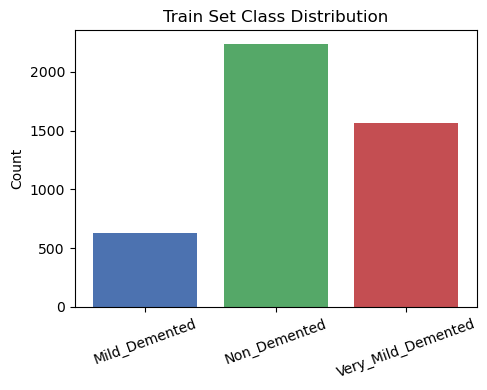

In [10]:
train_targets = np.array(train_dataset.targets)
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
print("학습 데이터 클래스별 개수:", dict(zip(CLASS_NAMES, class_counts)))

plt.figure(figsize=(5, 4))
plt.bar(CLASS_NAMES, class_counts, color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("Train Set Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

# 클래스별 가중치 = 1 / 빈도
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_targets]
sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### 샘플 이미지 확인

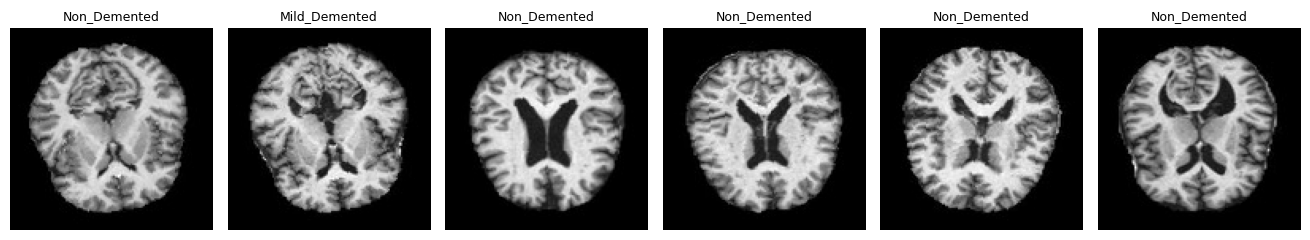

In [11]:
def show_samples(dataset, class_names, n=6):
    fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.5))
    indices = random.sample(range(len(dataset)), n)
    for ax, idx in zip(axes, indices):
        img, label = dataset[idx]
        img = img.squeeze().numpy() * 0.5 + 0.5  # 역정규화
        ax.imshow(img, cmap="gray")
        ax.set_title(class_names[label], fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("sample_images.png", dpi=150)
    plt.show()

show_samples(train_dataset, CLASS_NAMES)

## 2. 경량 CNN 모델 정의

Conv-BN-ReLU-Pool 블록 4개로 구성된 작은 CNN입니다.
128x128 입력 기준 파라미터 수는 약 50만~100만개 수준으로,
CPU에서도 빠르게 학습 가능합니다.

In [12]:
class LightCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 128x128 -> 64x64
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 64x64 -> 32x32
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 32x32 -> 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 4: 16x16 -> 8x8  (Grad-CAM에서 이 블록의 출력을 사용)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

model = LightCNN(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"총 파라미터 수: {total_params:,}")

총 파라미터 수: 98,019


## 3. 학습

클래스 불균형을 sampler뿐 아니라 loss에도 반영하기 위해
CrossEntropyLoss에 class weight를 함께 적용합니다.

In [13]:
EPOCHS = 8
LR = 1e-3

class_weight_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)

    return total_loss / total, correct / total


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

start_time = time.time()
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

print(f"\n총 학습 시간: {(time.time() - start_time)/60:.1f}분")

# 모델 저장 (보고서/추후 재사용용)
torch.save(model.state_dict(), "light_cnn_alzheimer.pth")

Epoch 1/8 | Train Loss: 0.8517 Acc: 0.4767 | Val Loss: 1.2347 Acc: 0.4316
Epoch 2/8 | Train Loss: 0.8062 Acc: 0.5179 | Val Loss: 0.9987 Acc: 0.5189
Epoch 3/8 | Train Loss: 0.7862 Acc: 0.5396 | Val Loss: 1.0652 Acc: 0.4842
Epoch 4/8 | Train Loss: 0.7485 Acc: 0.5648 | Val Loss: 1.9854 Acc: 0.2789
Epoch 5/8 | Train Loss: 0.7601 Acc: 0.5502 | Val Loss: 0.8393 Acc: 0.5547
Epoch 6/8 | Train Loss: 0.7311 Acc: 0.5675 | Val Loss: 0.9984 Acc: 0.5368
Epoch 7/8 | Train Loss: 0.7221 Acc: 0.5754 | Val Loss: 1.1999 Acc: 0.4895
Epoch 8/8 | Train Loss: 0.6909 Acc: 0.5869 | Val Loss: 1.5952 Acc: 0.3537

총 학습 시간: 10.6분


### 학습 곡선 시각화

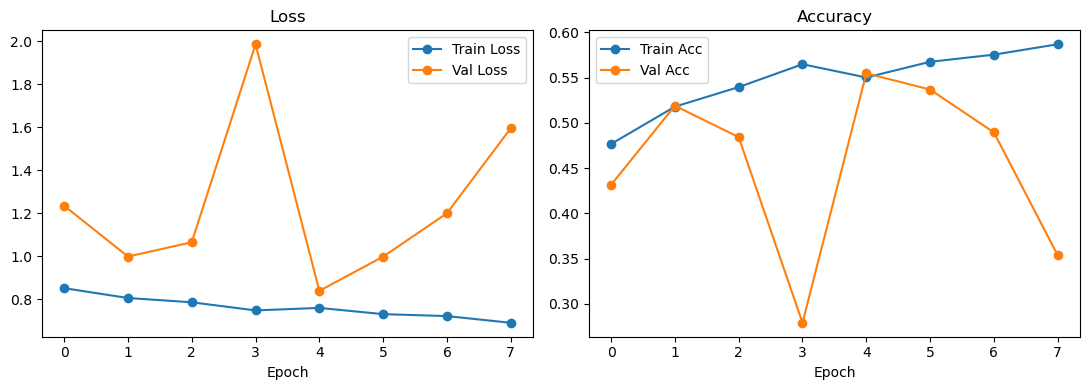

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(history["val_loss"], label="Val Loss", marker="o")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train Acc", marker="o")
axes[1].plot(history["val_acc"], label="Val Acc", marker="o")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

## 4. 테스트 (최종 평가)

In [15]:
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


test_labels, test_preds = get_predictions(model, test_loader)
test_acc = (test_labels == test_preds).mean()
print(f"Test Accuracy: {test_acc:.4f}\n")

print("=== Classification Report ===")
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=3))

Test Accuracy: 0.3670

=== Classification Report ===
                    precision    recall  f1-score   support

     Mild_Demented      0.221     0.985     0.361       135
      Non_Demented      0.925     0.306     0.460       480
Very_Mild_Demented      0.363     0.205     0.262       336

          accuracy                          0.367       951
         macro avg      0.503     0.499     0.361       951
      weighted avg      0.626     0.367     0.376       951



### Confusion Matrix

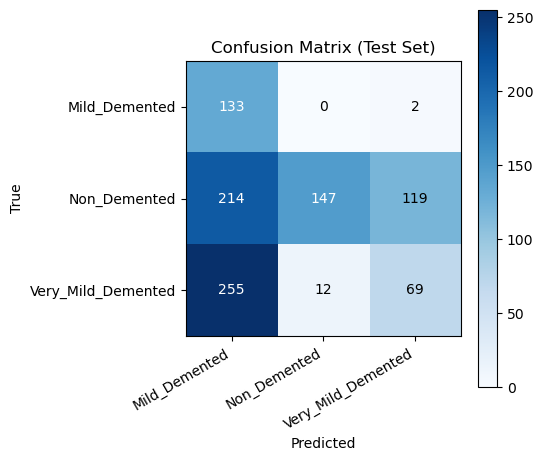

In [16]:
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (Test Set)")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 5. Grad-CAM 시각화

모델이 이미지의 어느 영역을 보고 분류 결정을 내렸는지 확인합니다.
마지막 conv 블록(`features[-4]`, 즉 4번째 Conv2d)의 activation과 gradient를 사용합니다.

정분류 샘플의 Grad-CAM:


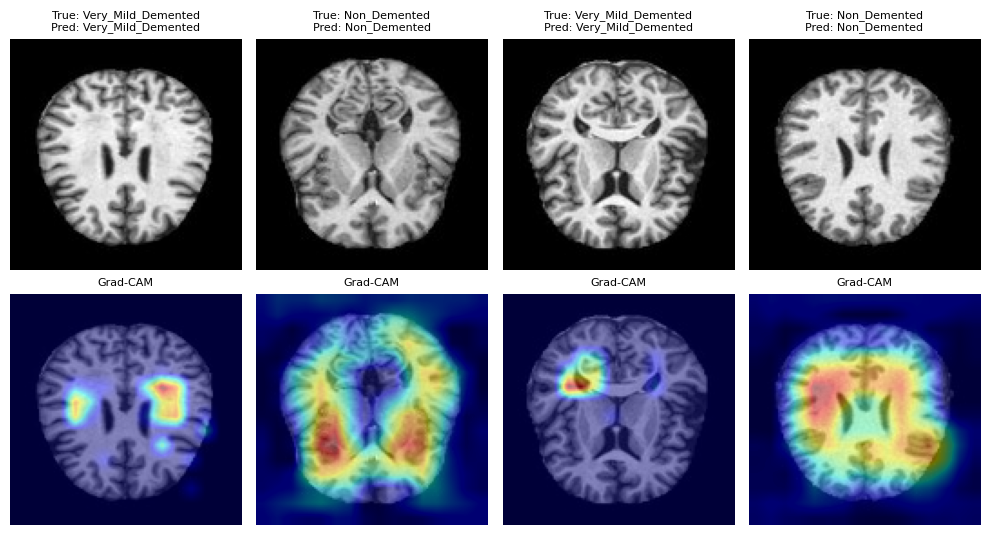


오분류 샘플의 Grad-CAM (있는 경우):


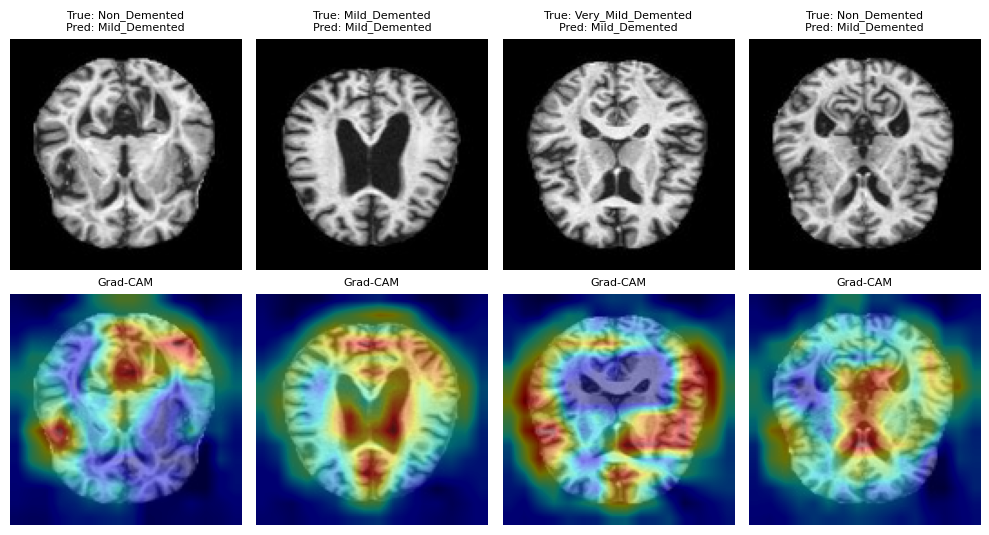

In [17]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        # gradient의 채널별 평균을 가중치로 사용 (GAP)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


# 마지막 conv layer 지정 (features 안의 4번째 Conv2d, index 12)
target_layer = model.features[12]
gradcam = GradCAM(model, target_layer)


def visualize_gradcam(dataset, model, gradcam, class_names, n=4, only_correct=True):
    fig, axes = plt.subplots(2, n, figsize=(2.5 * n, 5.5))
    shown = 0
    indices = list(range(len(dataset)))
    random.shuffle(indices)

    for idx in indices:
        if shown >= n:
            break
        img, true_label = dataset[idx]
        input_tensor = img.unsqueeze(0).to(DEVICE)

        cam, pred_label = gradcam.generate(input_tensor)
        is_correct = (pred_label == true_label)
        if only_correct and not is_correct:
            continue

        img_np = img.squeeze().numpy() * 0.5 + 0.5

        axes[0, shown].imshow(img_np, cmap="gray")
        axes[0, shown].set_title(
            f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}",
            fontsize=8
        )
        axes[0, shown].axis("off")

        axes[1, shown].imshow(img_np, cmap="gray")
        axes[1, shown].imshow(cam, cmap="jet", alpha=0.45)
        axes[1, shown].set_title("Grad-CAM", fontsize=8)
        axes[1, shown].axis("off")

        shown += 1

    plt.tight_layout()
    plt.savefig("gradcam_results.png", dpi=150)
    plt.show()


print("정분류 샘플의 Grad-CAM:")
visualize_gradcam(test_dataset, model, gradcam, CLASS_NAMES, n=4, only_correct=True)

print("\n오분류 샘플의 Grad-CAM (있는 경우):")
visualize_gradcam(test_dataset, model, gradcam, CLASS_NAMES, n=4, only_correct=False)

## 6. 결과 요약 (보고서용 메모)

- 전체 파라미터 수, Test Accuracy, 클래스별 Precision/Recall을 위 출력에서 확인
- Confusion Matrix에서 Mild_Demented(데이터가 가장 적은 클래스)의 오분류 경향 확인
- Grad-CAM에서 모델이 실제로 뇌실(ventricle) 확장이나 해마 주변 위축 영역에
  주목하는지, 아니면 무관한 영역(두개골 경계 등)을 보는지가 핵심 분석 포인트
- 한계: 2D 슬라이스 기반이라 3D 구조 정보 손실, 데이터 출처/수집 조건 불명확,
  외부 데이터셋 검증 부재